In [57]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [58]:
burnin = 1000
beta = 0.3
N = 1000
seed = 1
n = 50

In [59]:
key = jax.random.key(seed)
jax.config.update("jax_enable_x64", True)

In [60]:
def project(v, n):
    return v - jnp.dot(v, n)/jnp.dot(n, n) * n

def log_r(x, xi, y, xi_prime, beta):
  return 0.5 * (jnp.linalg.norm(x)**2 - jnp.linalg.norm(y)**2) + (1 / (2 * beta**2)) * (jnp.linalg.norm(xi)**2 - jnp.linalg.norm(xi_prime)**2)

def compute_reverse(x, y, n, beta):
    return project(x-jnp.sqrt(1-beta**2)*y, n)

In [61]:
def manifold(d):

    def F(x):
        return jnp.linalg.norm(x - 1)**2 - d

    x0 = jnp.zeros(d,dtype=jnp.float64)
    nx0 = jax.grad(F)(x0)

    def manifoldproject(x, n, tol=1e-6, maxiter=200):
        def f(val):
            a,i = val
            ff = lambda a: F(x + a * n)
            fff = ff(a)
            dff = jax.grad(ff)(a)
            return (a-fff/dff, i+1)
        def cond(val):
            a,i = val
            return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
        a,_ = jax.lax.while_loop(cond, f, (0.0,0))
        success = lambda a: jnp.abs(F(x + a * n))<tol
        return jnp.where(success(a), x + a * n, x)

    return F, x0, nx0, manifoldproject

In [62]:
def PCN(key, beta, d=10):
    F, x0, nx0, manifoldproject = manifold(d)
    keylist = jax.random.split(key, N+burnin)

    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, y, xi_prime, beta)
        acc = (jnp.log(jax.random.uniform(current_key, dtype=jnp.float64)) < R)
        ## vErify reverse projection
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin, acc, 0)
        it += 1
        return (x, nx, accs, it), R

    (_, _, accs, _), Rs = jax.lax.scan(sampleStep, (x0, nx0, 0, 0), keylist)
    return np.mean(Rs[burnin:]), accs/N

In [63]:
stats = []
rs = []
# test_x = np.int64(2**jnp.linspace(1,n+1,n))
test_x = range(n)
for test_dim in test_x:

  test_dim += 1
  test_dim *= 100
  beta = test_dim**(-0.5)
  r, out = PCN(key, beta, test_dim)
  stats = np.append(stats, out)
  rs = np.append(rs, r)

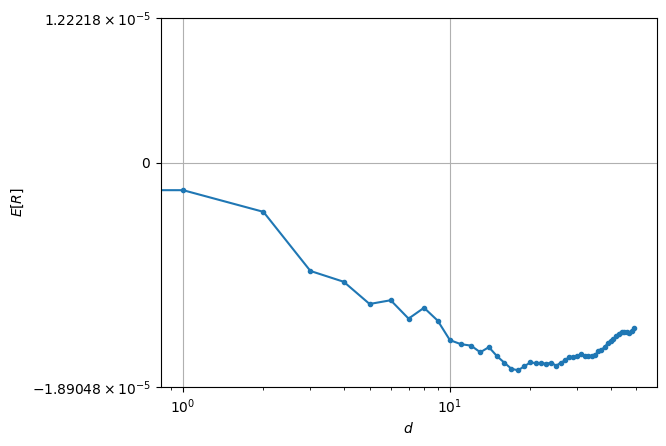

In [64]:
plt.plot(test_x, rs,'.-')
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$d$')
plt.ylabel(r'$E[R]$')
plt.grid()

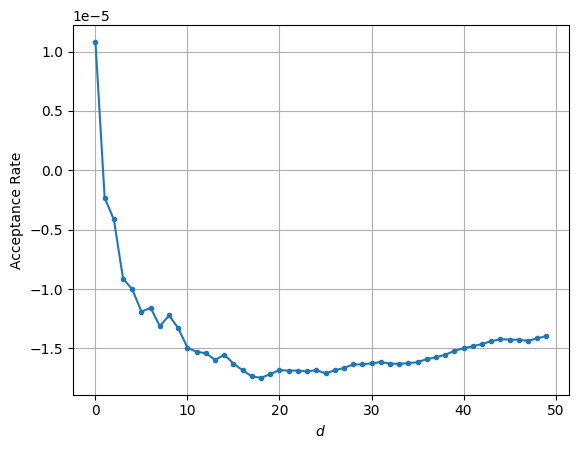

In [66]:
plt.plot(test_x, rs,'.-')
#plt.xscale('log')
#plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$d$')
plt.ylabel('Acceptance Rate')
plt.grid()